Decision Tree for Classification - 2 classes



In [ ]:
# -*- coding: utf-8 -*-

import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Create the dataset
data = {
    'a1': [True, True, False, False, False, True, True, True, False, False],
    'a2': ['Hot', 'Hot', 'Hot', 'Cool', 'Cool', 'Cool', 'Hot', 'Hot', 'Cool', 'Cool'],
    'a3': ['High', 'High', 'High', 'Normal', 'Normal', 'High', 'High', 'Normal', 'Normal', 'High'],
    'Classification': ['No', 'No', 'Yes', 'Yes', 'Yes', 'No', 'No', 'Yes', 'Yes', 'Yes']
}

data

{'a1': [True, True, False, False, False, True, True, True, False, False],
 'a2': ['Hot',
  'Hot',
  'Hot',
  'Cool',
  'Cool',
  'Cool',
  'Hot',
  'Hot',
  'Cool',
  'Cool'],
 'a3': ['High',
  'High',
  'High',
  'Normal',
  'Normal',
  'High',
  'High',
  'Normal',
  'Normal',
  'High'],
 'Classification': ['No',
  'No',
  'Yes',
  'Yes',
  'Yes',
  'No',
  'No',
  'Yes',
  'Yes',
  'Yes']}

In [ ]:

# Convert to DataFrame
df = pd.DataFrame(data)

# Convert categorical data to numerical data
label_encoders = {}
for column in df.columns:
    le = LabelEncoder()
    df[column] = le.fit_transform(df[column])
    label_encoders[column] = le
    print(df)


   a1    a2      a3 Classification
0   1   Hot    High             No
1   1   Hot    High             No
2   0   Hot    High            Yes
3   0  Cool  Normal            Yes
4   0  Cool  Normal            Yes
5   1  Cool    High             No
6   1   Hot    High             No
7   1   Hot  Normal            Yes
8   0  Cool  Normal            Yes
9   0  Cool    High            Yes
   a1  a2      a3 Classification
0   1   1    High             No
1   1   1    High             No
2   0   1    High            Yes
3   0   0  Normal            Yes
4   0   0  Normal            Yes
5   1   0    High             No
6   1   1    High             No
7   1   1  Normal            Yes
8   0   0  Normal            Yes
9   0   0    High            Yes
   a1  a2  a3 Classification
0   1   1   0             No
1   1   1   0             No
2   0   1   0            Yes
3   0   0   1            Yes
4   0   0   1            Yes
5   1   0   0             No
6   1   1   0             No
7   1   1   1       

In [ ]:

# Split the dataset into features and target
X = df.drop('Classification', axis=1)
y = df['Classification']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialize the Decision Tree Classifier with entropy as the criterion
clf = DecisionTreeClassifier(criterion='entropy')

clf

DecisionTreeClassifier(criterion='entropy')

In [ ]:
# Train the classifier
clf.fit(X_train, y_train)

# Make predictions
y_pred = clf.predict(X_test)

# Evaluate the classifier
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')
print(classification_report(y_test, y_pred, target_names=['No', 'Yes']))


Accuracy: 1.00
              precision    recall  f1-score   support

          No       1.00      1.00      1.00         2
         Yes       1.00      1.00      1.00         1

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



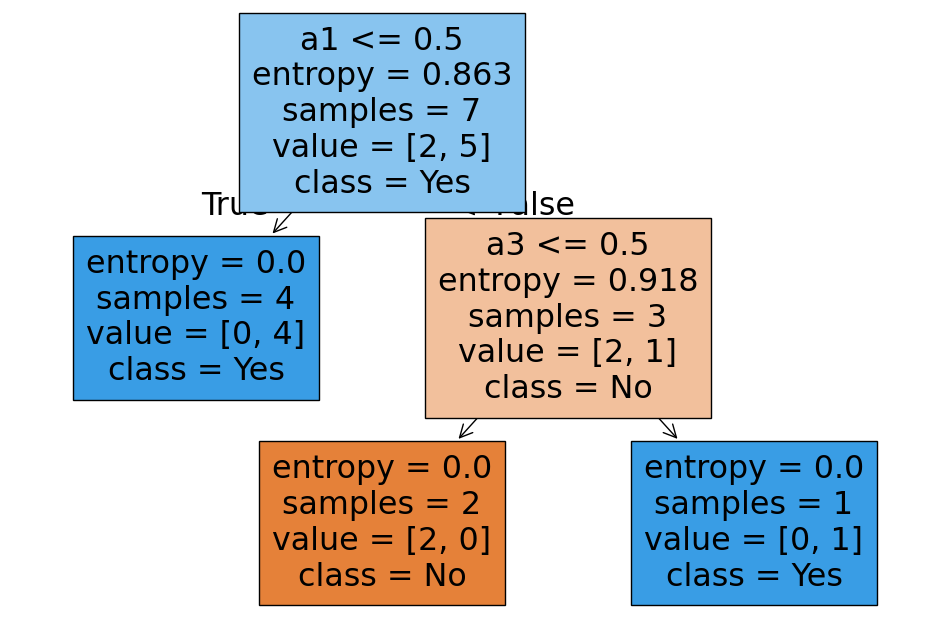

In [ ]:
# Optionally, visualize the decision tree
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
plot_tree(clf, filled=True, feature_names=X.columns, class_names=['No', 'Yes'])
plt.show()

Decision Tree - Iris

In [ ]:
df1=pd.read_csv("iris (1).csv")
df1.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

X = df1.drop('species', axis=1)
Y = df1['species']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

model = DecisionTreeClassifier(criterion="entropy")
model.fit(X_train,Y_train)

y_pred = model.predict(X_test)
y_pred

array(['Iris-versicolor', 'Iris-setosa', 'Iris-virginica',
       'Iris-versicolor', 'Iris-versicolor', 'Iris-setosa',
       'Iris-versicolor', 'Iris-virginica', 'Iris-versicolor',
       'Iris-versicolor', 'Iris-virginica', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-versicolor', 'Iris-virginica',
       'Iris-versicolor', 'Iris-versicolor', 'Iris-virginica',
       'Iris-setosa', 'Iris-virginica', 'Iris-setosa', 'Iris-virginica',
       'Iris-virginica', 'Iris-virginica', 'Iris-virginica',
       'Iris-virginica', 'Iris-setosa', 'Iris-setosa'], dtype=object)

In [ ]:
accuracy = accuracy_score(Y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')


Accuracy: 1.00


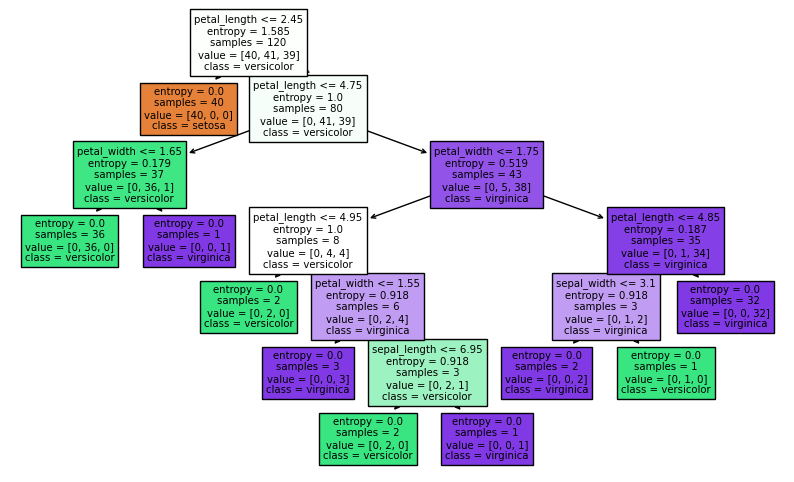

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plot_tree(model, feature_names=['sepal_length',	'sepal_width',	'petal_length',	'petal_width'], class_names=['setosa','versicolor','virginica'], filled=True)
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(Y_test, y_pred)
print(cm)

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


Decision Tree - Drug

In [ ]:
df2=pd.read_csv("drug.csv")

df2.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,drugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,drugY


In [ ]:
label_encoders = {}
for column in ['Sex', 'BP', 'Cholesterol', 'Drug']:
    le = LabelEncoder()
    df2[column] = le.fit_transform(df2[column])
    label_encoders[column] = le
    print(df2)

     Age  Sex      BP Cholesterol  Na_to_K   Drug
0     23    0    HIGH        HIGH   25.355  drugY
1     47    1     LOW        HIGH   13.093  drugC
2     47    1     LOW        HIGH   10.114  drugC
3     28    0  NORMAL        HIGH    7.798  drugX
4     61    0     LOW        HIGH   18.043  drugY
..   ...  ...     ...         ...      ...    ...
195   56    0     LOW        HIGH   11.567  drugC
196   16    1     LOW        HIGH   12.006  drugC
197   52    1  NORMAL        HIGH    9.894  drugX
198   23    1  NORMAL      NORMAL   14.020  drugX
199   40    0     LOW      NORMAL   11.349  drugX

[200 rows x 6 columns]
     Age  Sex  BP Cholesterol  Na_to_K   Drug
0     23    0   0        HIGH   25.355  drugY
1     47    1   1        HIGH   13.093  drugC
2     47    1   1        HIGH   10.114  drugC
3     28    0   2        HIGH    7.798  drugX
4     61    0   1        HIGH   18.043  drugY
..   ...  ...  ..         ...      ...    ...
195   56    0   1        HIGH   11.567  drugC
196   16

In [ ]:
X=df2.drop('Drug', axis=1)
Y=df2['Drug']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

model = DecisionTreeClassifier(criterion="entropy")
model.fit(X_train,Y_train)

y_pred = model.predict(X_test)
y_pred

array([3, 4, 3, 2, 4, 4, 4, 3, 0, 3, 0, 3, 4, 0, 1, 4, 1, 3, 2, 4, 1, 3,
       3, 4, 4, 4, 2, 3, 4, 3, 4, 2, 2, 4, 0, 4, 3, 0, 4, 0])

In [ ]:
accuracy = accuracy_score(Y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')

Accuracy: 1.00


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(Y_test, y_pred)
print(cm)

[[ 6  0  0  0  0]
 [ 0  3  0  0  0]
 [ 0  0  5  0  0]
 [ 0  0  0 11  0]
 [ 0  0  0  0 15]]


Regression Tree - Petrol Consumption

In [ ]:
df3=pd.read_csv("petrol_consumption.csv")

df3.head()

,Petrol_tax,Average_income,Paved_Highways,Population_Driver_licence(%),Petrol_Consumption
0,9.0,3571,1976,0.525,541
1,9.0,4092,1250,0.572,524
2,9.0,3865,1586,0.580,561
3,7.5,4870,2351,0.529,414
4,8.0,4399,431,0.544,410


In [ ]:
X=df3.drop('Petrol_Consumption', axis=1)
Y=df3['Petrol_Consumption']

X_train, X_test, Y_train, Y_test=train_test_split(X,Y, test_size=0.2, random_state=42)
from sklearn.tree import DecisionTreeRegressor

model=DecisionTreeRegressor(random_state=42)

model.fit(X_train, Y_train)

y_pred=model.predict(X_test)
y_pred

array([603., 632., 580., 714., 510., 644., 414., 968., 580., 541.])

In [ ]:
from sklearn.metrics import mean_absolute_error,mean_squared_error
import numpy as np

mae = mean_absolute_error(Y_test, y_pred)
mse = mean_squared_error(Y_test, y_pred)
rmse = np.sqrt(mse)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)

Mean Absolute Error: 94.3
Mean Squared Error: 17347.7
Root Mean Squared Error: 131.7106677532234
